Eğitim Başlatılıyor...
Timestep 281/25000	Ortalama Skor: 28.10
Timestep 433/25000	Ortalama Skor: 21.65
Timestep 623/25000	Ortalama Skor: 20.77
Timestep 770/25000	Ortalama Skor: 19.25
Timestep 894/25000	Ortalama Skor: 17.88
Timestep 1016/25000	Ortalama Skor: 16.93
Timestep 1148/25000	Ortalama Skor: 16.40
Timestep 1301/25000	Ortalama Skor: 16.26
Timestep 1444/25000	Ortalama Skor: 16.04
Timestep 1566/25000	Ortalama Skor: 15.66
Timestep 1690/25000	Ortalama Skor: 14.09
Timestep 1793/25000	Ortalama Skor: 13.60
Timestep 1911/25000	Ortalama Skor: 12.88
Timestep 2017/25000	Ortalama Skor: 12.47
Timestep 2153/25000	Ortalama Skor: 12.59
Timestep 2279/25000	Ortalama Skor: 12.63
Timestep 2398/25000	Ortalama Skor: 12.50
Timestep 2508/25000	Ortalama Skor: 12.07
Timestep 2664/25000	Ortalama Skor: 12.20
Timestep 2880/25000	Ortalama Skor: 13.14
Timestep 3081/25000	Ortalama Skor: 13.91
Timestep 3232/25000	Ortalama Skor: 14.39
Timestep 3342/25000	Ortalama Skor: 14.31
Timestep 3467/25000	Ortalama Skor: 14.5

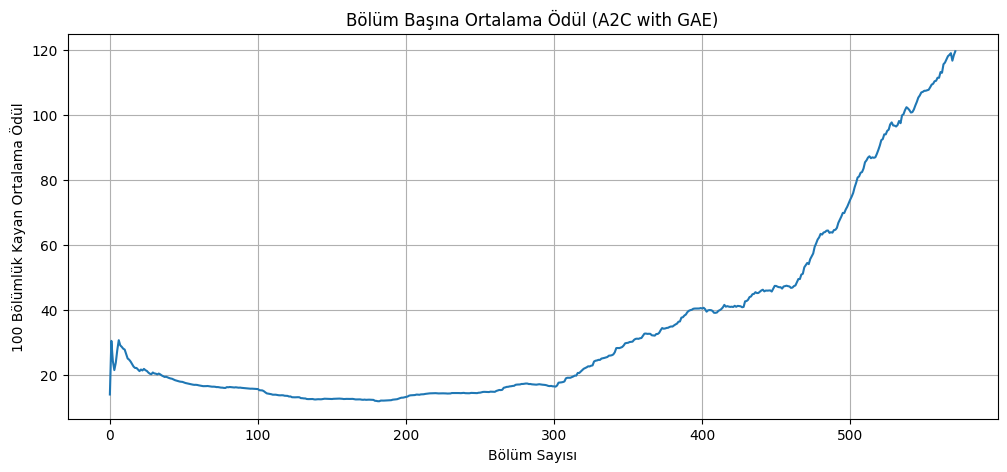

In [1]:
import gymnasium as gym
import torch
import numpy as np
import random
import os
import sys
from collections import deque
import matplotlib.pyplot as plt

# --- Proje Kök Dizinini Python Path'e Ekleme ---
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# --- Ajan Modülümüzü İçe Aktarma ---
from src.agents.a2c_minimal import A2CAgent

# --- Kurulum ve Seed Ayarları ---
def set_seed(seed_value=42):
    torch.manual_seed(seed_value)
    np.random.seed(seed_value)
    random.seed(seed_value)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(42)

# --- Hiperparametreler ---
env = gym.make("CartPole-v1")
obs_space_size = env.observation_space.shape[0]
action_space_size = env.action_space.n
agent = A2CAgent(obs_space_size, action_space_size, device)

total_timesteps = 25000
n_steps = 5 # Her 5 adımda bir güncelleme yap

# --- Loglama için ---
scores_deque = deque(maxlen=100)
avg_scores = []
timestep_idx = 0

# --- Eğitim Döngüsü ---
state, _ = env.reset()
current_episode_reward = 0

print("Eğitim Başlatılıyor...")
while timestep_idx < total_timesteps:
    
    # Adım 1: Rollout Verisi Topla (n_steps kadar)
    states_list, actions_list, log_probs, values, rewards, dones = [], [], [], [], [], []
    
    for _ in range(n_steps):
        timestep_idx += 1
        states_list.append(state)
        
        action, log_prob, value = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        actions_list.append(torch.tensor([action], device=device))
        log_probs.append(log_prob)
        values.append(value)
        rewards.append(torch.tensor([reward], device=device))
        dones.append(torch.tensor([done], device=device))

        state = next_state
        current_episode_reward += reward
        
        if done:
            scores_deque.append(current_episode_reward)
            avg_scores.append(np.mean(scores_deque))
            current_episode_reward = 0
            state, _ = env.reset()
            if len(avg_scores) % 10 == 0:
                print(f'\rTimestep {timestep_idx}/{total_timesteps}\tOrtalama Skor: {np.mean(scores_deque):.2f}')

    # Adım 2: Politikayı Güncelle
    with torch.no_grad():
        _, next_value = agent.network(torch.from_numpy(state).float().unsqueeze(0).to(device))
    
    # Toplanan verileri tensörlere dönüştür
    states_tensor = torch.from_numpy(np.array(states_list)).float().to(device)
    actions_tensor = torch.cat(actions_list)
    log_probs = torch.cat(log_probs)
    values = torch.cat(values).squeeze(-1) # Squeeze boyutu düzelt
    rewards = torch.cat(rewards).squeeze(-1)
    dones = torch.cat(dones).squeeze(-1)
    
    # Ajanın update_policy fonksiyonuna doğru formatta veriyi yolla
    rollout = (states_tensor, actions_tensor, rewards, log_probs, values, dones, next_value)
    
    agent.update_policy(rollout)

print("Eğitim Tamamlandı.")
env.close()

# --- Sonuçları Görselleştirme ---
plt.figure(figsize=(12, 5))
plt.plot(avg_scores)
plt.title('Bölüm Başına Ortalama Ödül (A2C with GAE)')
plt.xlabel('Bölüm Sayısı')
plt.ylabel('100 Bölümlük Kayan Ortalama Ödül')
plt.grid(True)
plt.show()

